# 데이터 분석 미니 프로젝트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import glob

In [2]:
# 한글 폰트 설정
import platform

from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')
    print('Linux system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

Linux system... font set to NanumGothic


## 1. 데이터 불러오기
- 주민등록인구 및 세대현황 : 총인구 / 세대수 / 세대당 인구 / 성비
- 연령별 인구현황 : 10세 구간 + 성별
- 세대원수별 세대수 : 1인 세대 ~ 10인 이상 세대

In [3]:
path = './data_pop'

# 주민등록인구및세대현황
pop_files = sorted(glob.glob(f"{path}/*주민등록인구및세대현황*.csv"))
print(pop_files)

pop1 = pd.read_csv(pop_files[0], encoding="cp949", thousands=",")
pop2 = pd.read_csv(pop_files[1], encoding="cp949", thousands=",")
pop  = pop1.merge(pop2, on="행정구역", how="outer") # 합치기
print(pop.shape)

['./data_pop/200812_201512_주민등록인구및세대현황_연간.csv', './data_pop/201612_202512_주민등록인구및세대현황_연간.csv']
(55, 109)


In [4]:
# 연령별인구현황
age_files = sorted(glob.glob(f"{path}/*연령별인구현황*.csv"))
print(age_files)

age1 = pd.read_csv(age_files[0], encoding="cp949", thousands=",")
age2 = pd.read_csv(age_files[1], encoding="cp949", thousands=",")
age3 = pd.read_csv(age_files[2], encoding="cp949", thousands=",")
age  = age1.merge(age2, on="행정구역", how="outer").merge(age3, on="행정구역", how="outer")
print(age.shape)

['./data_pop/200812_201312_연령별인구현황_연간.csv', './data_pop/201412_201912_연령별인구현황_연간.csv', './data_pop/202012_202512_연령별인구현황_연간.csv']
(55, 703)


In [5]:
# 세대원수별세대수
house_file = glob.glob(f"{path}/*세대원수별*.csv")[0]
house = pd.read_csv(house_file, encoding="cp949", thousands=",")          # 2016~2025
print(house.shape)

(54, 111)


In [6]:
pop.head()

,행정구역,2008년_총인구수,2008년_세대수,2008년_세대당 인구,2008년_남자 인구수,2008년_여자 인구수,2008년_남여 비율,2009년_총인구수,2009년_세대수,2009년_세대당 인구,...,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_총인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
0,경기도 경기도 성남시 (4113000000),942447,367675,2.56,471033,471414,1.00,962726.0,375386.0,2.56,...,2.23,451408.0,461601.0,0.98,905794.0,409252.0,2.21,447380.0,458414.0,0.98
1,경기도 경기도 성남시 분당구 (4113500000),428858,157171,2.73,209987,218871,0.96,460688.0,168352.0,2.74,...,2.44,228331.0,242823.0,0.94,469833.0,193385.0,2.43,227507.0,242326.0,0.94
2,경기도 경기도 성남시 수정구 (4113100000),248452,105403,2.36,126314,122138,1.03,242161.0,103663.0,2.34,...,2.01,118695.0,116182.0,1.02,232389.0,116200.0,2.00,117449.0,114940.0,1.02
3,경기도 경기도 성남시 중원구 (4113300000),265137,105101,2.52,134732,130405,1.03,259877.0,103371.0,2.51,...,2.06,104382.0,102596.0,1.02,203572.0,99667.0,2.04,102424.0,101148.0,1.01
4,경기도 성남시 분당구 구미1동(4113566500),19872,7295,2.72,9790,10082,0.97,19287.0,7077.0,2.73,...,2.31,7813.0,8369.0,0.93,16089.0,6937.0,2.32,7762.0,8327.0,0.93


In [7]:
pop['행정구역'].head(20).tolist()

['경기도 경기도 성남시 (4113000000)',
 '경기도 경기도 성남시 분당구 (4113500000)',
 '경기도 경기도 성남시 수정구 (4113100000)',
 '경기도 경기도 성남시 중원구 (4113300000)',
 '경기도 성남시 분당구 구미1동(4113566500)',
 '경기도 성남시 분당구 구미동(4113567000)',
 '경기도 성남시 분당구 금곡동(4113566200)',
 '경기도 성남시 분당구 백현동(4113565700)',
 '경기도 성남시 분당구 분당동(4113551000)',
 '경기도 성남시 분당구 삼평동(4113565500)',
 '경기도 성남시 분당구 서현1동(4113558000)',
 '경기도 성남시 분당구 서현2동(4113559000)',
 '경기도 성남시 분당구 수내1동(4113552000)',
 '경기도 성남시 분당구 수내2동(4113553000)',
 '경기도 성남시 분당구 수내3동(4113554000)',
 '경기도 성남시 분당구 야탑1동(4113562000)',
 '경기도 성남시 분당구 야탑2동(4113563000)',
 '경기도 성남시 분당구 야탑3동(4113564000)',
 '경기도 성남시 분당구 운중동(4113568000)',
 '경기도 성남시 분당구 이매1동(4113560000)']

In [8]:
print(age.shape)
age.columns[:14].tolist()

(55, 703)


['행정구역',
 '2008년_계_총인구수',
 '2008년_계_연령구간인구수',
 '2008년_계_0~9세',
 '2008년_계_10~19세',
 '2008년_계_20~29세',
 '2008년_계_30~39세',
 '2008년_계_40~49세',
 '2008년_계_50~59세',
 '2008년_계_60~69세',
 '2008년_계_70~79세',
 '2008년_계_80~89세',
 '2008년_계_90~99세',
 '2008년_계_100세 이상']

## 2. 데이터 전처리

In [9]:
# '경기도 경기도 성남시 수정구 (4113100000)'  ->  '수정구'
def gu_name(s):
    s = s.split('(')[0].strip()
    s = s.replace('경기도', '').replace('성남시', '').strip()
    return s

test = ['경기도 경기도 성남시 (4113000000)',
        '경기도 성남시 수정구 (4113100000)',
        '경기도 성남시 분당구 정자동(4113554500)']
[gu_name(t) for t in test]

['', '수정구', '분당구 정자동']

In [10]:
gus = ['수정구', '중원구', '분당구']

def pick_gu(df):
    d = df.copy()
    d['지역'] = d['행정구역'].map(gu_name)
    return d[d['지역'].isin(gus)].set_index('지역')

pop_gu = pick_gu(pop)
age_gu = pick_gu(age)
house_gu = pick_gu(house)

pop_gu.index.tolist()

['분당구', '수정구', '중원구']

## 3. 세 구의 인구 변화

In [11]:
# 연도별 총인구수만 추출
tot_cols = [c for c in pop.columns if '총인구수' in c]

인구추이 = pop_gu[tot_cols].T
인구추이.index = [c.split('년')[0] for c in 인구추이.index]
인구추이

지역,분당구,수정구,중원구
2008,428858.0,248452.0,265137.0
2009,460688.0,242161.0,259877.0
2010,481027.0,241070.0,258093.0
2011,488328.0,236123.0,254872.0
2012,490735.0,233997.0,253883.0
2013,495018.0,228167.0,256349.0
2014,499087.0,223539.0,251982.0
2015,501889.0,219531.0,250004.0
2016,503830.0,232841.0,237909.0
2017,500212.0,236932.0,230366.0


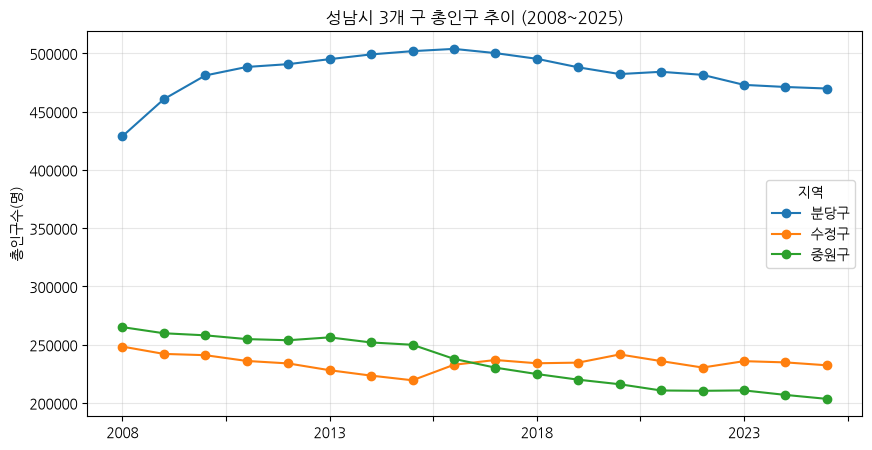

In [12]:
인구추이.plot(figsize=(10,5), marker='o')
plt.title('성남시 3개 구 총인구 추이 (2008~2025)')
plt.ylabel('총인구수(명)')
plt.grid(alpha=0.3)
plt.show()

1. 분당구 증가 -> 판교 입주 이후 우하향
2. 중원구는 계속 우하향
3. 수정구는 우하향 하는가 싶더니 갑자기 한번씩 위로 튐

## 4. 수정구 분석

In [13]:
# 특정 구의 동별 인구 변화 (2016 → 2025)
def 구_동별(gu):
    d = age[age['행정구역'].str.contains(gu) & age['행정구역'].str.contains('동')].copy()
    d['동'] = d['행정구역'].map(lambda s: s.split('(')[0].split(gu)[-1].strip())
    d = d.dropna(subset=['2016년_계_총인구수'])
    d['2016'] = d['2016년_계_총인구수'].astype(int)
    d['2025'] = d['2025년_계_총인구수'].astype(int)
    d['증감'] = d['2025'] - d['2016']
    return d[['동','2016','2025','증감']].sort_values('증감', ascending=False).reset_index(drop=True)

수정_동별 = 구_동별('수정구')
수정_동별

,동,2016,2025,증감
0,위례동,24206,45473,21267
1,고등동,1723,11797,10074
2,신흥2동,22154,31635,9481
3,시흥동,3229,3548,319
4,신촌동,4743,4511,-232
5,신흥3동,11090,10670,-420
6,양지동,10644,8923,-1721
7,복정동,12241,10453,-1788
8,신흥1동,14495,12046,-2449
9,단대동,17008,14162,-2846


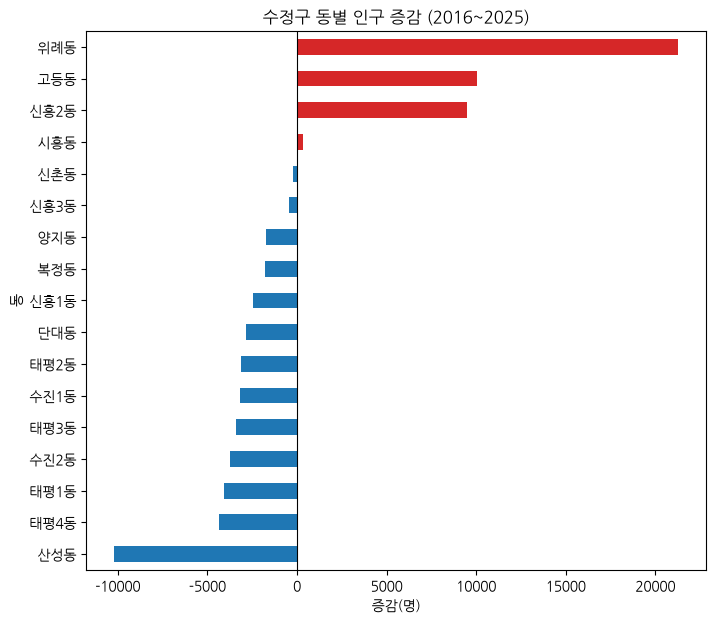

In [14]:
# 동별 증감을 막대로 (증가=빨강, 감소=파랑)
색 = ['#d62728' if v > 0 else '#1f77b4' for v in 수정_동별['증감']]
수정_동별.set_index('동')['증감'].plot(kind='barh', figsize=(8,7), color=색)
plt.title('수정구 동별 인구 증감 (2016~2025)')
plt.xlabel('증감(명)')
plt.axvline(0, color='k', lw=0.8)
plt.gca().invert_yaxis()
plt.show()

- 위례동, 고등동, 신흥2동 (모두 신규 입주 — 위례신도시 / 고등지구 / 신흥2동 재개발)
- 나머지 원도심 동은 대부분 감소

In [15]:
신규동 = ['위례동', '고등동', '신흥2동']   # 위례신도시 / 고등지구 / 신흥2동 재개발

def 신구_분해(gu, 신규):
    d = 구_동별(gu)
    return pd.Series({
        '신규택지 동': d[d['동'].isin(신규)]['증감'].sum(),
        '원도심 동'  : d[~d['동'].isin(신규)]['증감'].sum(),
        '구 전체'    : d['증감'].sum(),
    })

신구_분해('수정구', 신규동)

신규택지 동    40822
원도심 동    -41274
구 전체       -452
dtype: int64

- 원도심 14개 동 감소분(−41,274)을 위례·고등·신흥2(+40,822)가 거의 상쇄
- 그래서 구 전체는 −452명(제자리)처럼 보임 = 착시
- 구 단위 통계만 보면 수정구는 멀쩡해 보인다 → 구가 아니라 동으로 봐야 하는 이유

## 5. 중원구 분석
- 중원구도 같은 방식으로 분해해 나란히 비교

In [16]:
중원_동별 = 구_동별('중원구')
중원_동별

,동,2016,2025,증감
0,금광1동,12726,19608,6882
1,성남동,30809,31835,1026
2,중앙동,17740,16585,-1155
3,도촌동,27989,25878,-2111
4,은행1동,12174,9289,-2885
5,하대원동,22472,19542,-2930
6,상대원3동,14123,11054,-3069
7,금광2동,27958,23438,-4520
8,상대원1동,28311,22454,-5857
9,은행2동,27555,20978,-6577


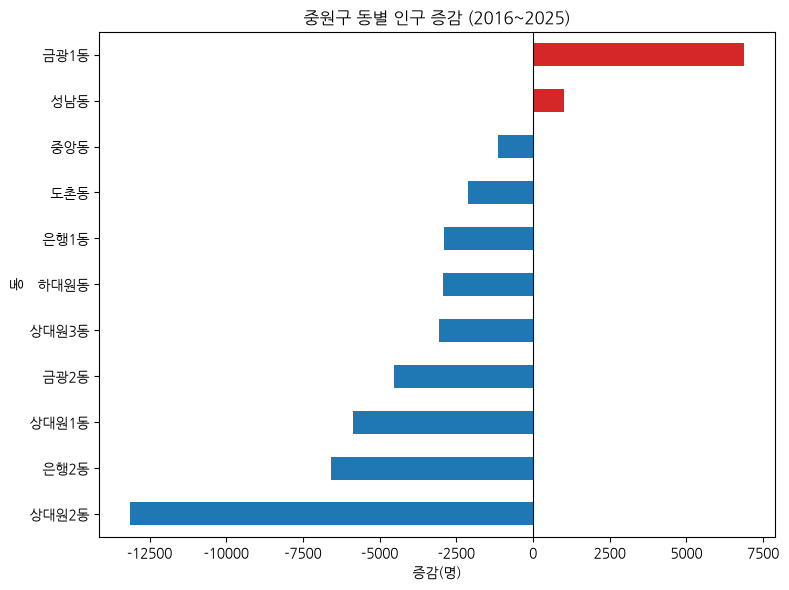

In [17]:
# 중원구 동별 증감
색 = ['#d62728' if v > 0 else '#1f77b4' for v in 중원_동별['증감']]
중원_동별.set_index('동')['증감'].plot(kind='barh', figsize=(8,6), color=색)
plt.title('중원구 동별 인구 증감 (2016~2025)')
plt.xlabel('증감(명)')
plt.axvline(0, color='k', lw=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [18]:
비교 = pd.DataFrame({
    '수정구': 신구_분해('수정구', ['위례동','고등동','신흥2동']),
    '중원구': 신구_분해('중원구', ['금광1동']),
})
비교

,수정구,중원구
신규택지 동,40822,6882
원도심 동,-41274,-41219
구 전체,-452,-34337


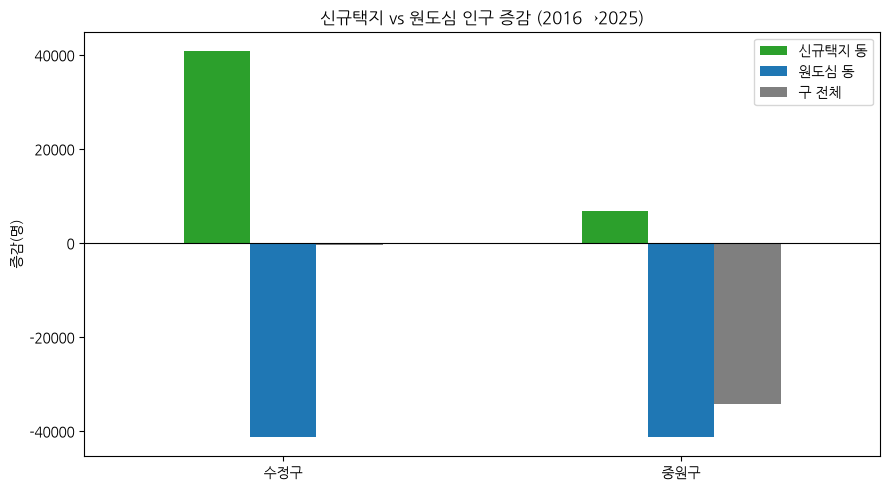

In [19]:
# 신규택지 vs 원도심 (수정 vs 중원)
ax = 비교.T.plot(kind='bar', figsize=(9,5), color=['#2ca02c','#1f77b4','#7f7f7f'])
plt.title('신규택지 vs 원도심 인구 증감 (2016→2025)')
plt.ylabel('증감(명)')
plt.axhline(0, color='k', lw=0.8)
plt.xticks(rotation=0)
plt.legend(title=None)
plt.tight_layout()
plt.show()

- 원도심 동 감소: 수정 −41,274 vs 중원 −41,219 → 거의 동일 (쌍둥이)
- 차이는 신규택지뿐: 수정엔 위례(+4만), 중원엔 없음(금광1동 +6,882)
- 구 총량만 −452 vs −34,337로 갈렸을 뿐, 원도심 문제는 동일

## 6. 원도심의 문제1
- 60세 이상 비율 + 실제 아이 수

In [20]:
# 특정 연령대 합계 비율(%)을 연도별로 계산하는 함수
years = [c.split('년')[0] for c in age.columns if c.endswith('년_계_총인구수')]

def 연령비율(bands):
    out = {}
    for y in years:
        tot = age_gu[f'{y}년_계_총인구수']
        val = sum(age_gu[f'{y}년_계_{b}'] for b in bands)
        out[y] = val / tot * 100
    return pd.DataFrame(out).T   # 행: 연도, 열: 구

고령비율 = 연령비율(['60~69세','70~79세','80~89세','90~99세','100세 이상'])
고령비율.round(1)

지역,분당구,수정구,중원구
2008,11.2,12.4,11.5
2009,11.4,13.1,12.2
2010,11.6,14.0,13.1
2011,11.8,14.7,13.5
2012,12.3,15.6,14.4
2013,12.8,16.6,15.0
2014,13.4,17.6,16.1
2015,14.2,18.9,17.3
2016,14.9,19.5,18.5
2017,15.8,20.4,19.8


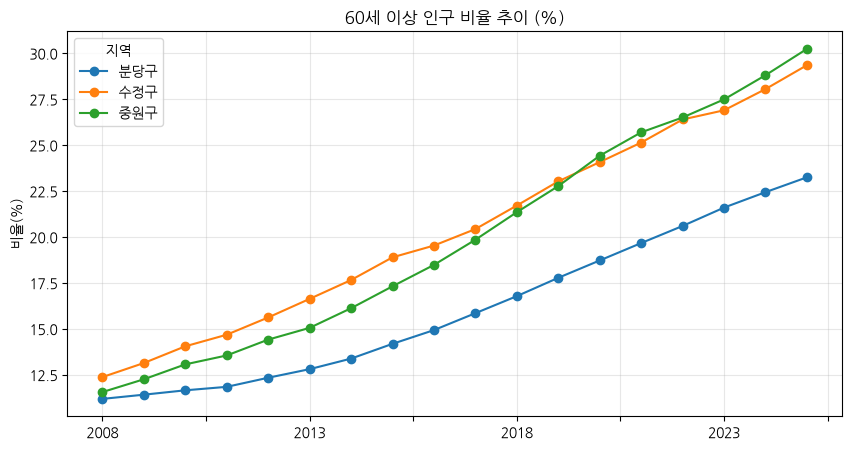

In [21]:
고령비율.plot(figsize=(10,5), marker='o')
plt.title('60세 이상 인구 비율 추이 (%)')
plt.ylabel('비율(%)')
plt.grid(alpha=0.3)
plt.show()

- 수정, 중원 2025년 약 30% → 훨씬 빠른 고령화
- 분당도 11%(2008) → 23%(2025)

In [22]:
# 0~9세: 비율 + 실제 아이 수·감소율
유소년비율 = 연령비율(['0~9세'])
아이수 = pd.DataFrame({y: age_gu[f'{y}년_계_0~9세'] for y in ['2008', '2025']})

유소년_요약 = pd.DataFrame({
    '비율08(%)'      : 유소년비율.loc['2008'],
    '비율25(%)'      : 유소년비율.loc['2025'],
    '비율_감소율(%)'  : (유소년비율.loc['2025'] - 유소년비율.loc['2008']) / 유소년비율.loc['2008'] * 100,
    '아이수08'       : 아이수['2008'].astype(int),
    '아이수25'       : 아이수['2025'].astype(int),
    '아이수_감소율(%)': (아이수['2025'] - 아이수['2008']) / 아이수['2008'] * 100,
}).round(1)
유소년_요약

,비율08(%),비율25(%),비율_감소율(%),아이수08,아이수25,아이수_감소율(%)
지역,,,,,,
분당구,10.4,6.6,-36.1,44553,31170,-30.0
수정구,9.7,5.5,-43.9,24184,12697,-47.5
중원구,9.4,5.1,-46.3,24981,10294,-58.8


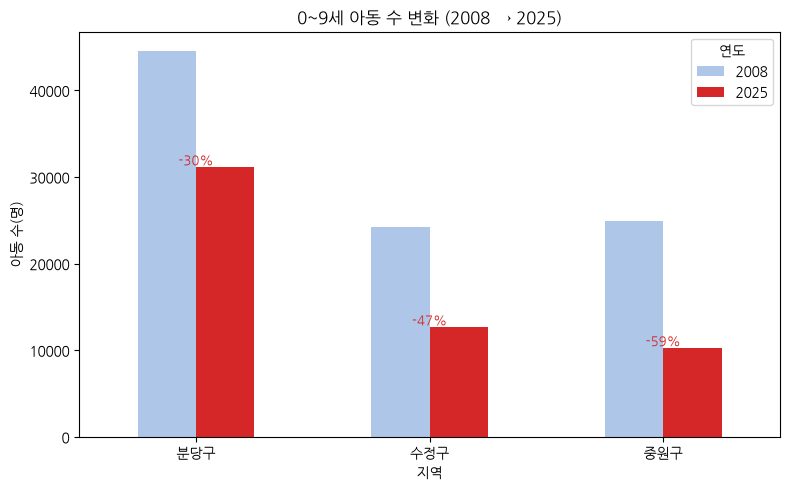

In [23]:
# 0~9세 아동 수 (2008 vs 2025)
아이수_int = 아이수[['2008','2025']].astype(int)
ax = 아이수_int.plot(kind='bar', figsize=(8,5), color=['#aec7e8','#d62728'])
plt.title('0~9세 아동 수 변화 (2008 → 2025)')
plt.ylabel('아동 수(명)')
plt.xticks(rotation=0)
for i, 지역 in enumerate(아이수_int.index):
    감소 = (아이수_int.loc[지역,'2025'] - 아이수_int.loc[지역,'2008']) / 아이수_int.loc[지역,'2008'] * 100
    plt.annotate(f'{감소:.0f}%', (i, 아이수_int.loc[지역,'2025']),
                 ha='center', va='bottom', fontsize=9, color='#d62728')
plt.legend(title='연도')
plt.tight_layout()
plt.show()

- 유소년 비율 감소율은 세 구 비슷 (분당 −37 / 수정 −44 / 중원 −46%) → 저출생은 전국 공통
- 실제 아이 수로 보면 분당 −30% vs 중원 −59% (절반 넘게 감소)

## 7. 원도심의 문제2
- 세대당 인구, 1인 세대

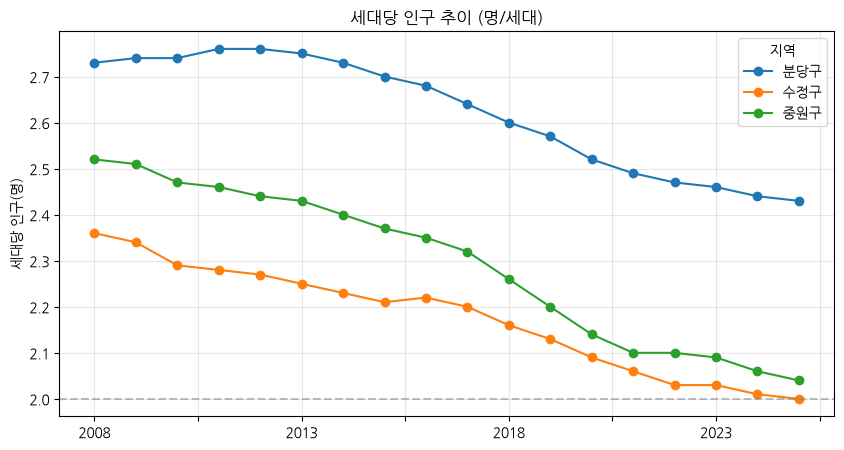

In [24]:
# 세대당 인구 추이
세대당_cols = [c for c in pop.columns if '세대당 인구' in c]

세대당인구 = pop_gu[세대당_cols].T
세대당인구.index = [c.split('년')[0] for c in 세대당인구.index]

세대당인구.plot(figsize=(10,5), marker='o')
plt.title('세대당 인구 추이 (명/세대)')
plt.ylabel('세대당 인구(명)')
plt.axhline(2.0, color='gray', ls='--', alpha=0.5)   # 2명 선
plt.grid(alpha=0.3)
plt.show()

In [25]:
# 1인 세대 비율 (2016~2025 데이터)
hyears = [c.split('년')[0] for c in house.columns if '전체세대' in c]

one = {}
for y in hyears:
    tcol = [c for c in house.columns if c.startswith(y) and '전체세대' in c][0]
    scol = [c for c in house.columns if c.startswith(y) and '1인세대' in c][0]
    one[y] = house_gu[scol] / house_gu[tcol] * 100

일인세대비율 = pd.DataFrame(one).T
일인세대비율.loc[[hyears[0], hyears[-1]]].round(1)

지역,수정구,중원구,분당구
2016,41.8,37.4,27.4
2025,46.7,44.1,31.9


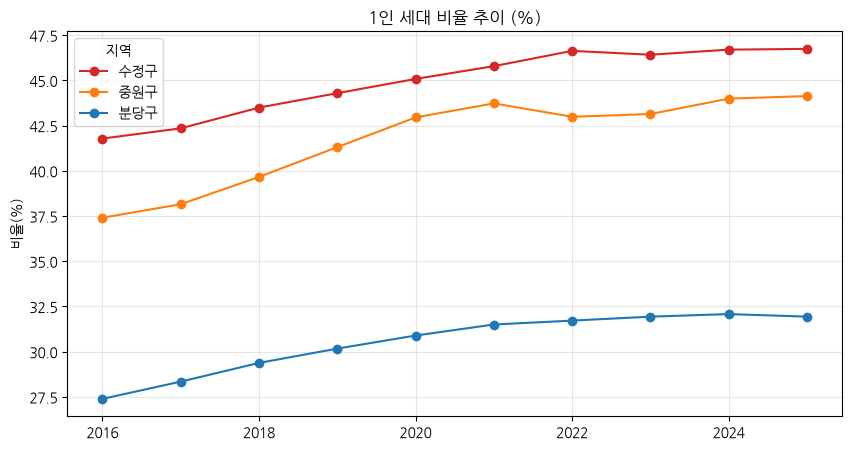

In [26]:
# 1인 세대 비율 추이 (2016 → 2025)
일인세대비율[['수정구','중원구','분당구']].plot(figsize=(10,5), marker='o',
    color=['#d62728','#ff7f0e','#1f77b4'])
plt.title('1인 세대 비율 추이 (%)')
plt.ylabel('비율(%)')
plt.grid(alpha=0.3)
plt.show()

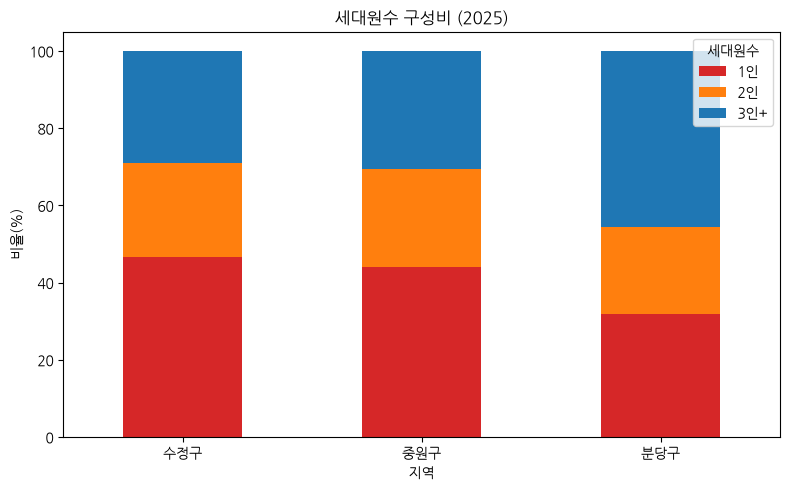

In [27]:
# 세대원수 구성 (2025): 1인 / 2인 / 3인 이상
def hcol(y, key): return [c for c in house.columns if c.startswith(y) and key in c][0]
_t = house_gu[hcol('2025','전체세대')]
_1 = house_gu[hcol('2025','1인세대')]
_2 = house_gu[hcol('2025','2인세대')]
세대구성 = pd.DataFrame({'1인': _1/_t*100, '2인': _2/_t*100,
                     '3인+': (_t-_1-_2)/_t*100}).loc[['수정구','중원구','분당구']]
세대구성.plot(kind='bar', stacked=True, figsize=(8,5),
           color=['#d62728','#ff7f0e','#1f77b4'])
plt.title('세대원수 구성비 (2025)')
plt.ylabel('비율(%)')
plt.xticks(rotation=0)
plt.legend(title='세대원수')
plt.tight_layout()
plt.show()

- 세대당 인구: 수정·중원 2명 미만, 분당 2.4명대
- 1인 세대 비율: 꾸준히 상승, 2025년 수정 46.7% / 중원 44.1% vs 분당 31.9%
- 세대원수 구성: 원도심은 1~2인 가구가 약 70%, 분당은 3인+ 가족가구가 45.5%

## 8. 신도시는 다같이 늙는다
- 신규 입주지 / 분당 / 원도심을 나이순으로 세우면, 셋은 딴 그룹이 아니라 같은 길 위 세 시점

In [28]:
# 동을 유형별로 나눠 2025 연령 프로필 (젊은 순 → 늙은 순)
신규택지동 = ['위례동', '고등동', '신흥2동', '금광1동']
elderly = ['60~69세','70~79세','80~89세','90~99세','100세 이상']

def 동_모으기(gu):
    d = age[age['행정구역'].str.contains(gu) & age['행정구역'].str.contains('동')].copy()
    d['동'] = d['행정구역'].map(lambda s: s.split('(')[0].split(gu)[-1].strip())
    return d

원도심_후보 = pd.concat([동_모으기('수정구'), 동_모으기('중원구')])
원도심_후보['유형'] = 원도심_후보['동'].map(lambda x: '신규택지' if x in 신규택지동 else '원도심')

def 프로필(df):
    tot = df['2025년_계_총인구수'].sum()
    e = sum(df[f'2025년_계_{b}'] for b in elderly).sum()
    k = df['2025년_계_0~9세'].sum()
    return pd.Series({'인구': int(tot), '60세+ %': e/tot*100,
                      '0~9세 %': k/tot*100, '고령÷유소년': e/k})

프로필표 = pd.DataFrame({
    '신규 입주지(2010s)': 프로필(원도심_후보[원도심_후보['유형']=='신규택지']),
    '분당(1990s)'     : 프로필(age[age['행정구역'].map(gu_name)=='분당구']),
    '원도심'          : 프로필(원도심_후보[원도심_후보['유형']=='원도심']),
}).T
프로필표.round(1)

,인구,60세+ %,0~9세 %,고령÷유소년
신규 입주지(2010s),108513.0,22.7,9.7,2.3
분당(1990s),469833.0,23.2,6.6,3.5
원도심,327448.0,32.1,3.8,8.4


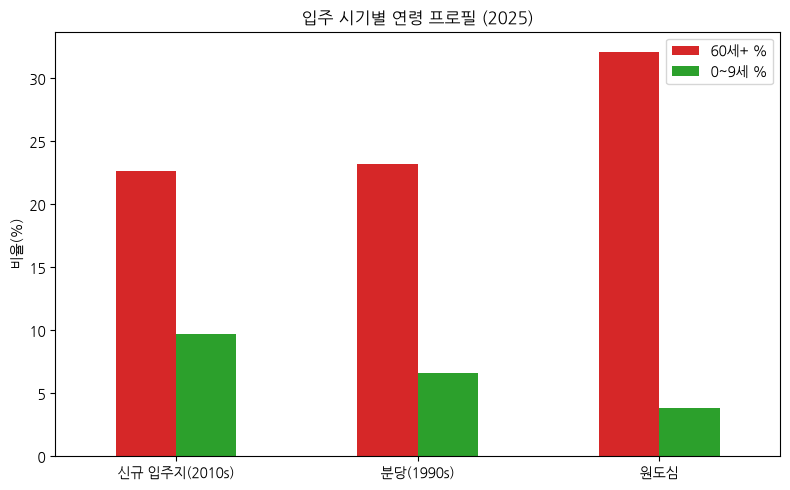

In [29]:
# 연령 프로필: 젊은 곳 → 늙은 곳 (2025)
프로필표[['60세+ %','0~9세 %']].plot(kind='bar', figsize=(8,5),
    color=['#d62728','#2ca02c'])
plt.title('입주 시기별 연령 프로필 (2025)')
plt.ylabel('비율(%)')
plt.xticks(rotation=0)
plt.legend(title=None)
plt.tight_layout()
plt.show()

- 젊은 순으로 세우면: 신규 입주지(60+ 22.7%) → 분당(23.2%) → 원도심(32.1%)
- 0~9세는 정반대: 9.7% → 6.6% → 3.8%
- 세 그룹이 아니라, 입주 시기가 만든 '나이 궤적' 위의 세 점 — 그럼 분당은 원도심으로 가는 중일까?

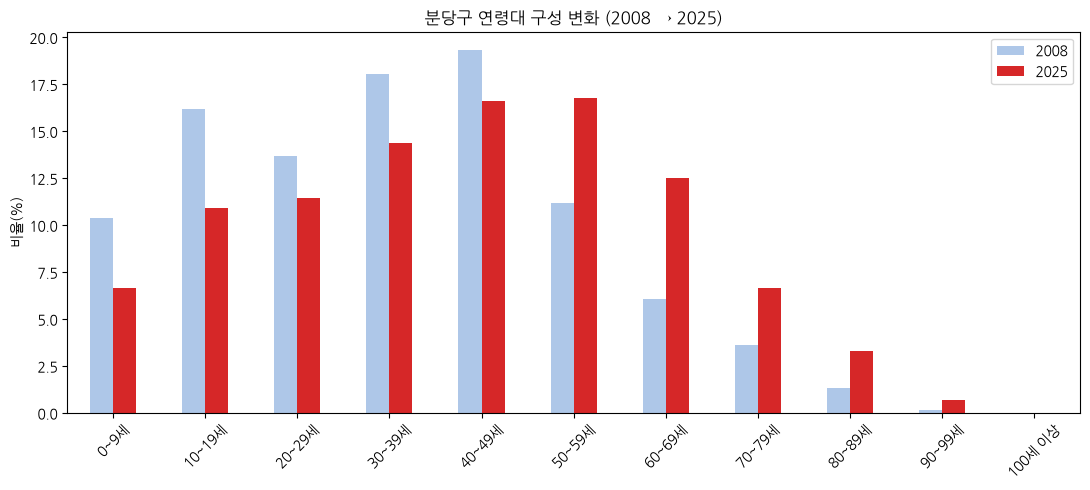

In [30]:
# 분당 연령 구성 변화 (2008 vs 2025) — 봉우리가 위로 이동 = 제자리 고령화
bands = ['0~9세','10~19세','20~29세','30~39세','40~49세','50~59세',
         '60~69세','70~79세','80~89세','90~99세','100세 이상']
분당 = age[age['행정구역'].map(gu_name)=='분당구']

def band_share(y):
    tot = 분당[f'{y}년_계_총인구수'].sum()
    return pd.Series({b: 분당[f'{y}년_계_{b}'].sum()/tot*100 for b in bands})

분당연령 = pd.DataFrame({'2008': band_share('2008'), '2025': band_share('2025')})
분당연령.plot(kind='bar', figsize=(11,5), color=['#aec7e8','#d62728'])
plt.title('분당구 연령대 구성 변화 (2008 → 2025)')
plt.ylabel('비율(%)')
plt.xticks(rotation=45)
plt.legend(title=None)
plt.tight_layout()
plt.show()

- 2008년엔 30~40대(입주민)가 봉우리 → 2025년 그 봉우리가 그대로 50~60대로 이동
- 새 사람이 안 들어오고, 있던 사람이 제자리에서 늙은 것 (원도심도 같은 모양, 더 진행)
- 즉 분당은 원도심의 20년 전 모습이자, 위례의 20년 뒤 모습 → 방치하면 같은 길

## 9. 결론 — 문제의 본질
- 본질: 신도시가 한꺼번에 입주해 한꺼번에 늙는다 (세대 순환이 없음)
- 위례(2010s) → 분당(1990s) → 원도심은 같은 궤적의 세 시점
- 구 통계는 이걸 가린다(수정구 착시) → 봐야 할 단위는 '입주 시기별 동네'

| 시점 | 신규 입주지 | 분당(1기) | 원도심 |
|---|---|---|---|
| 입주 시기 | 2010s | 1990s | 오래된 구도심 |
| 60세+ (2025) | 22.7% | 23.2% | 32.1% |
| 0~9세 (2025) | 9.7% | 6.6% | 3.8% |
| 상태 | 아직 젊음 | 고령화 진입 | 초고령 |
| 개입 시점 | 20~30년 여유 | 지금이 골든타임 | 이미 늦음 |

## 10. 지역별 정책 제언
핵심 한 줄: **'한꺼번에 늙는 신도시'의 사슬을 끊는다 = 세대 순환(연령 혼합) 장치를 심는다.**

**① 원도심 — 이미 늦음 → 완화 + 재생**
- 즉시: 독거노인 돌봄·안전망, 생활권 의료 (60+ 32%, 1인가구 46%)
- 전환: 도시재생·정비로 젊은 층 재유입(신흥2동 모델), 단 원주민 재정착 보장

**② 분당 — 골든타임 → 구조 리셋**
- 1기 신도시 재정비를 '재건축 물량'이 아니라 **연령 구조 리셋**으로 설계
- 재정비 시 소형·청년·임대주택 의무 혼합 → 젊은 층 재유입, 원도심 궤적 차단

**③ 신규 입주지 — 예방 → 처음부터 섞기**
- 신규 택지에 청년·1인·고령 주택 **연령 혼합 비율 의무화**(단일 연령대 쏠림 방지)
- 입주 단계에서 20~30년 뒤 **재정비 로드맵 예약** → 동시 노후 대비

→ 세 정책은 따로가 아니라 하나의 원리(세대 순환)를 시점별로 적용한 것.

## 11. 동별 인구 지도
- 성남시 행정동별 2025 인구를 지도에 표시 (색이 진할수록 인구 많음)
- 동 위에 마우스를 올리면 툴팁으로 구·동·인구 표시
- 경계 데이터: 행정안전부 행정동 경계 (vuski/admdongkor, 2025년판)

In [31]:
# 동별 인구 지도 (folium choropleth + 툴팁)
import folium, json
import branca.colormap as cm

geo = json.load(open('map_data/seongnam_admdong.geojson', encoding='utf-8'))

# census 2025 총인구를 (구, 동)으로 매핑
동인구 = {}
_d = age[age['행정구역'].str.contains('성남시') & age['행정구역'].str.contains('동')]
for _, r in _d.iterrows():
    if pd.isna(r['2025년_계_총인구수']):
        continue
    nm = r['행정구역'].split('(')[0].split()   # ['경기도','성남시','수정구','위례동']
    동인구[(nm[-2], nm[-1])] = int(r['2025년_계_총인구수'])

# geojson 속성에 인구 · 툴팁 필드 부여
for f in geo['features']:
    parts = f['properties']['adm_nm'].split()   # ['경기도','성남시수정구','위례동']
    gu, dong = parts[1].replace('성남시', ''), parts[-1]
    pop = 동인구.get((gu, dong))
    f['properties']['구'] = gu
    f['properties']['동'] = dong
    f['properties']['인구'] = pop or 0
    f['properties']['인구표시'] = f"{pop:,}명" if pop else "자료없음"

# 인구 색상 스케일
vals = [f['properties']['인구'] for f in geo['features'] if f['properties']['인구'] > 0]
colormap = cm.linear.YlOrRd_09.scale(min(vals), max(vals))
colormap.caption = '2025년 동별 총인구(명)'

지도 = folium.Map(location=[37.44, 127.14], zoom_start=12, tiles='cartodbpositron')
folium.GeoJson(
    geo,
    style_function=lambda x: {
        'fillColor': colormap(x['properties']['인구']) if x['properties']['인구'] else '#dddddd',
        'color': 'white', 'weight': 1, 'fillOpacity': 0.75,
    },
    tooltip=folium.GeoJsonTooltip(fields=['구', '동', '인구표시'],
                                  aliases=['구', '동', '인구']),
).add_to(지도)
colormap.add_to(지도)

지도.save('map_data/seongnam_pop_map.html')
지도